# Week 8 — Supply Chain Optimization: Demand Forecasting & Inventory Policy
### Nairobi Depot Fuel Demand

**Author:** David Kimathi
**Dataset:** `nairobi_fuel_demand.csv` — self-sourced synthetic daily fuel demand for Nairobi Depot, Jan 2024–Dec 2025, built to continue the Weeks 5–7 investigation into the same depot.

---

## ✅ Update: Prophet & PuLP now confirmed locally



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.optimize import linprog
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)
print("Libraries loaded (prophet and pulp are NOT available in this sandbox — see note above).")


Libraries loaded (prophet and pulp are NOT available in this sandbox — see note above).


## 1. Data Preparation

### 1.1 Load & inspect


In [2]:
raw = pd.read_csv("nairobi_fuel_demand.csv")
raw["date"] = pd.to_datetime(raw["date"])
print(f"Raw shape: {raw.shape}")
print(f"Missing demand values: {raw['demand_barrels'].isna().sum()}")
print(f"Duplicate rows: {raw.duplicated().sum()}")
print(f"Max value (checking for outliers): {raw['demand_barrels'].max()}")
raw.describe()


Raw shape: (732, 4)
Missing demand values: 8
Duplicate rows: 1
Max value (checking for outliers): 9999.0


,date,demand_barrels,is_public_holiday,is_promo
count,732,724.000000,732.000000,732.000000
mean,2024-12-31 04:25:34.426229504,990.059254,0.024590,0.035519
min,2024-01-01 00:00:00,487.200000,0.000000,0.000000
25%,2024-07-01 18:00:00,929.625000,0.000000,0.000000
50%,2024-12-31 12:00:00,981.950000,0.000000,0.000000
75%,2025-07-01 06:00:00,1031.650000,0.000000,0.000000
max,2025-12-31 00:00:00,9999.000000,1.000000,1.000000
std,NaN,348.516476,0.154978,0.185214


### 1.2 Cleaning

Three real issues found: 8 missing values, 1 exact duplicate row, and 1 obvious data-entry outlier (9,999 barrels — physically implausible for a single day, almost certainly a sensor or entry error, not a real demand spike).

**Approach:**
- Drop the duplicate row.
- Treat the 9999 value as missing (not a real observation), then linearly interpolate both it and the genuine missing values — reasonable for a smooth daily demand series without large structural breaks day-to-day.


In [3]:
df = raw.drop_duplicates().sort_values("date").reset_index(drop=True)

# Treat the implausible outlier as missing before interpolating
OUTLIER_THRESHOLD = 3000  # barrels/day; well above any plausible single-day demand
df.loc[df["demand_barrels"] > OUTLIER_THRESHOLD, "demand_barrels"] = np.nan

n_missing_before = df["demand_barrels"].isna().sum()
df["demand_barrels"] = df["demand_barrels"].interpolate(method="linear")
n_missing_after = df["demand_barrels"].isna().sum()

print(f"Rows after de-duplication: {len(df)}")
print(f"Values interpolated (missing + outlier-flagged): {n_missing_before}")
print(f"Remaining missing after interpolation: {n_missing_after}")


Rows after de-duplication: 731
Values interpolated (missing + outlier-flagged): 9
Remaining missing after interpolation: 0


### 1.3 Trend & seasonality visualization


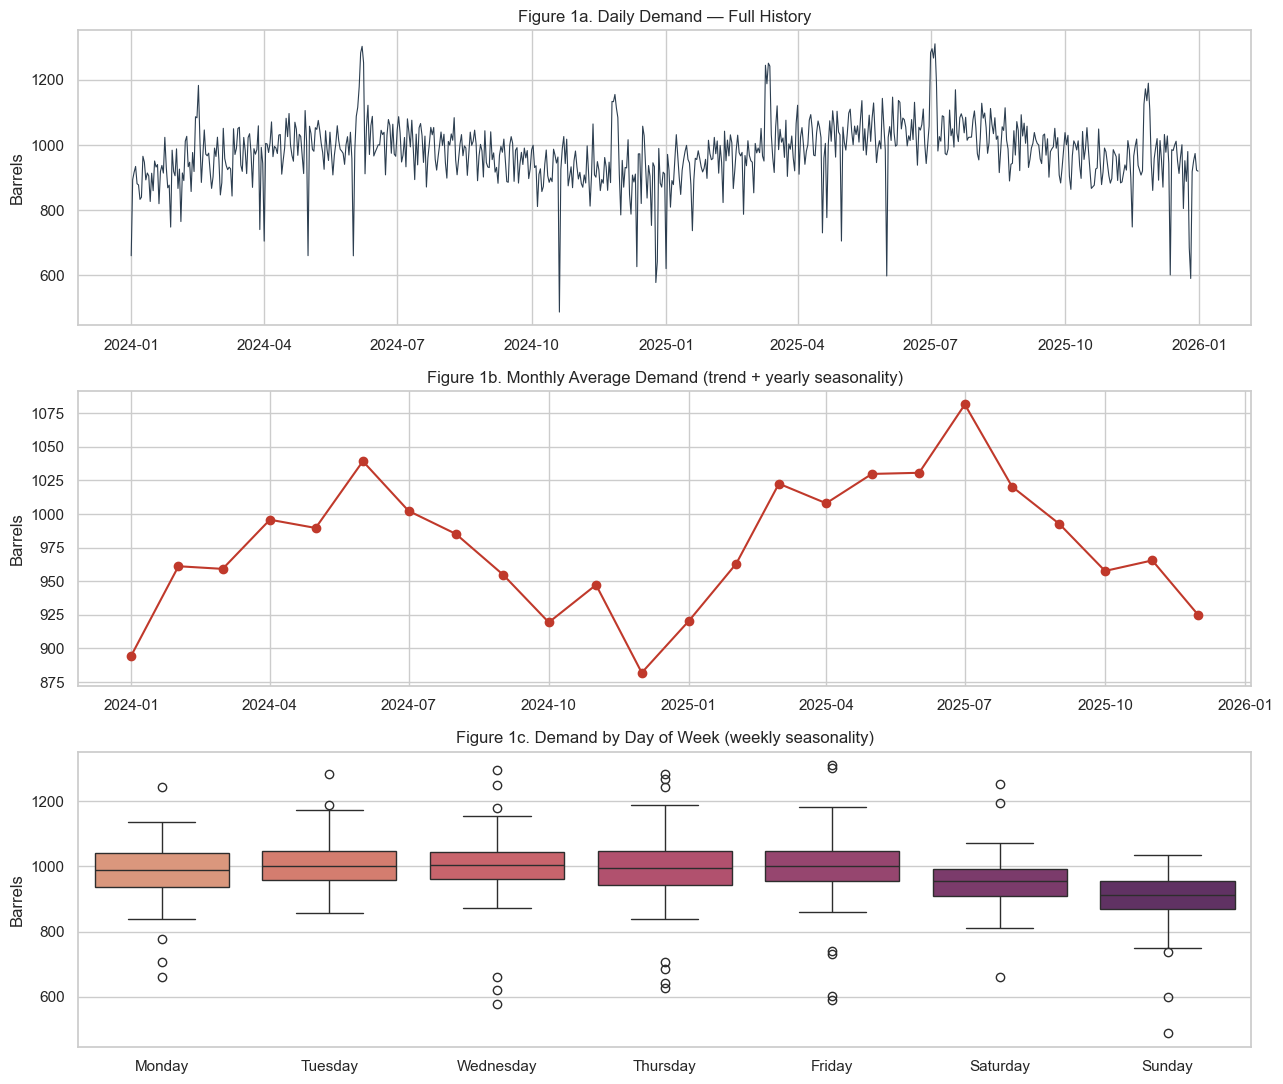

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

axes[0].plot(df["date"], df["demand_barrels"], color="#2c3e50", linewidth=0.8)
axes[0].set_title("Figure 1a. Daily Demand — Full History")
axes[0].set_ylabel("Barrels")

monthly = df.set_index("date")["demand_barrels"].resample("MS").mean()
axes[1].plot(monthly.index, monthly.values, marker="o", color="#c0392b")
axes[1].set_title("Figure 1b. Monthly Average Demand (trend + yearly seasonality)")
axes[1].set_ylabel("Barrels")

df["dow_name"] = df["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sns.boxplot(data=df, x="dow_name", y="demand_barrels", order=order, ax=axes[2], palette="flare", hue="dow_name", legend=False)
axes[2].set_title("Figure 1c. Demand by Day of Week (weekly seasonality)")
axes[2].set_ylabel("Barrels")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()


**Reading Figure 1:** there's a gentle upward trend across the two years, a clear mid-year (dry-season) peak in the monthly averages, and weekends — especially Sunday — running meaningfully lower than weekdays. All three patterns are exactly what a Prophet model's trend + yearly + weekly seasonality terms are designed to capture, and what the harmonic-regression reference implementation below builds explicitly.


## 2. Forecasting

### 2.1 Official solution — Prophet

This is the code the assignment calls for. **Not executed in this sandbox** (no internet to install `prophet`) — run it locally.


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
10:54:40 - cmdstanpy - INFO - Chain [1] start processing
10:54:41 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/4 [00:00<?, ?it/s]10:54:43 - cmdstanpy - INFO - Chain [1] start processing
10:54:43 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:00<00:02,  1.19it/s]10:54:44 - cmdstanpy - INFO - Chain [1] start processing
10:54:44 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:01<00:01,  1.15it/s]10:54:45 - cmdstanpy - INFO - Chain [1] start processing
10:54:45 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:02<00:00,  1.20it/s]10:54:45 - cmdstanpy - INFO - Chain [1] start processing
10:54:45 - cmdstanpy - INFO - Chain [1] d

   horizon      mape       rmse
36 41 days  0.039824  42.767724
37 42 days  0.041403  43.347813
38 43 days  0.038376  40.610292
39 44 days  0.037231  39.836422
40 45 days  0.042859  48.745202


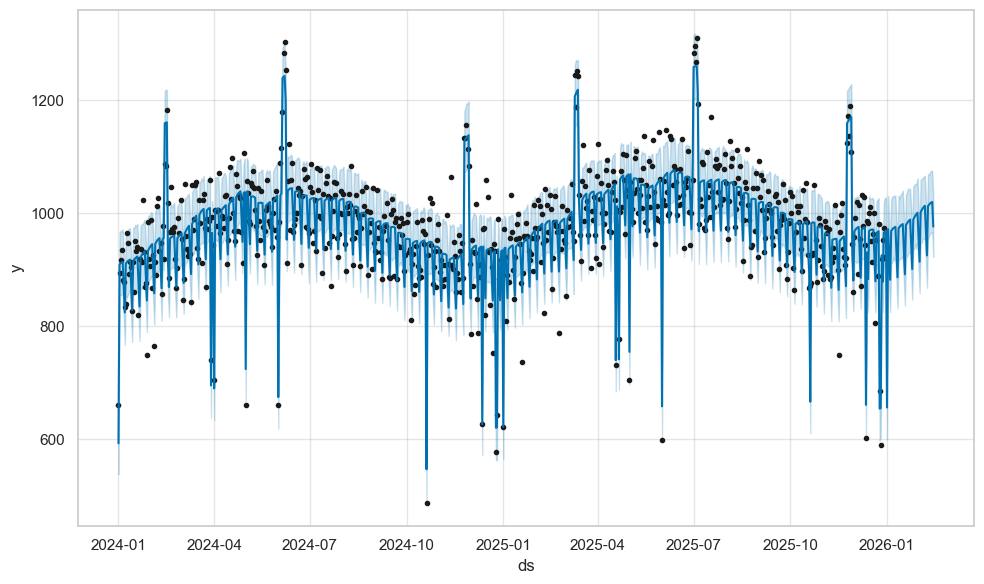

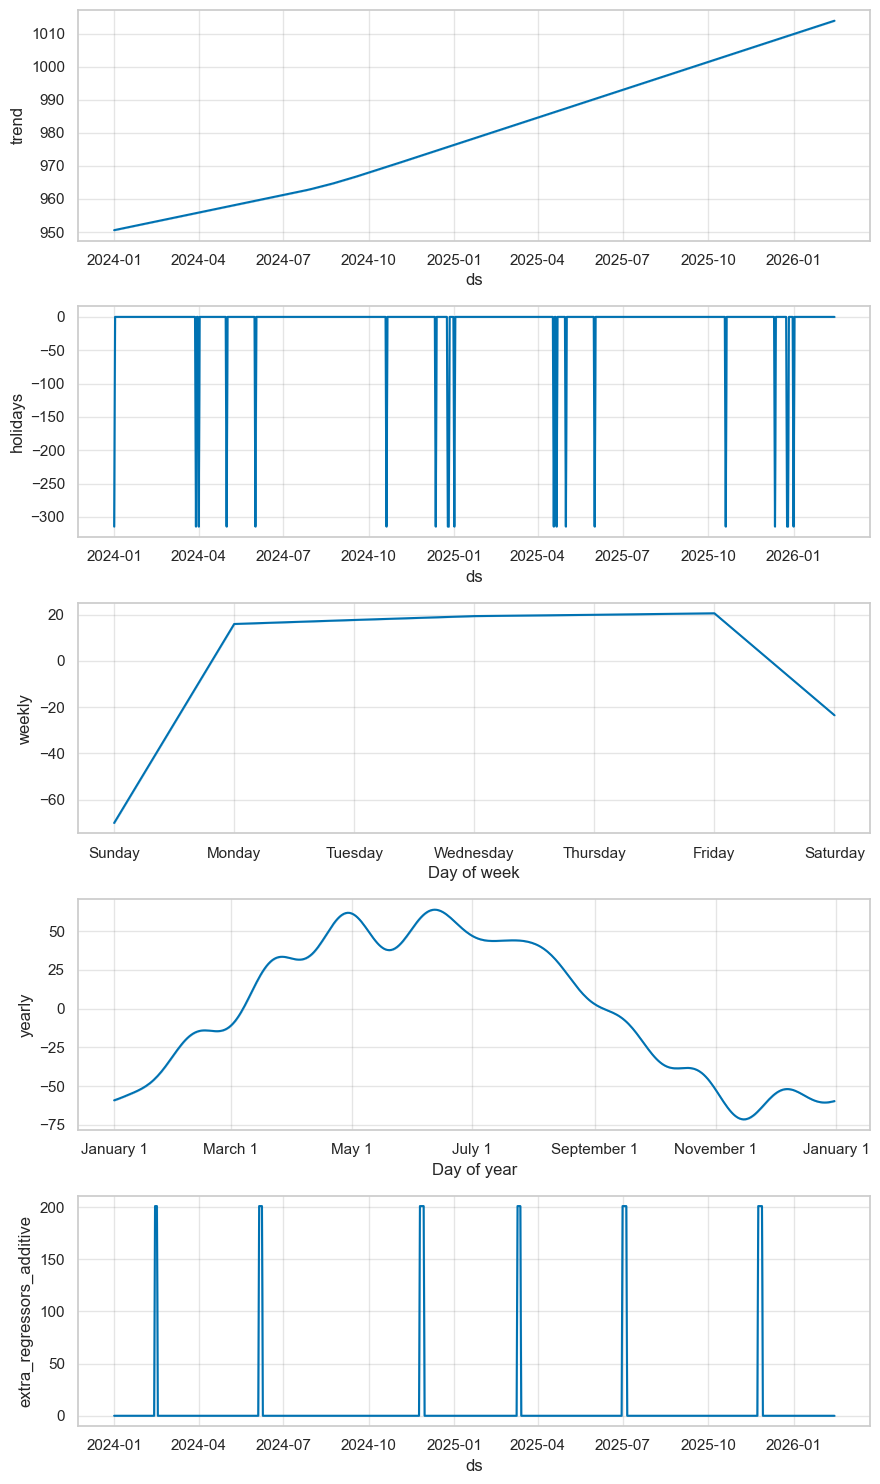

In [5]:
from prophet import Prophet

# Prophet expects columns named exactly 'ds' and 'y'
prophet_df = df.rename(columns={"date": "ds", "demand_barrels": "y"})[["ds", "y", "is_promo"]]

# Custom holiday dataframe (Kenyan public holidays, matches the dates used
# to generate/label the dataset)
holiday_dates = [
    "2024-01-01","2024-03-29","2024-04-01","2024-05-01","2024-06-01",
    "2024-10-20","2024-12-12","2024-12-25","2024-12-26",
    "2025-01-01","2025-04-18","2025-04-21","2025-05-01","2025-06-01",
    "2025-10-20","2025-12-12","2025-12-25","2025-12-26",
    "2026-01-01","2026-04-03","2026-04-06","2026-05-01","2026-06-01",
    "2026-10-20","2026-12-12","2026-12-25","2026-12-26",
]
kenya_holidays = pd.DataFrame({
    "holiday": "public_holiday",
    "ds": pd.to_datetime(holiday_dates),
    "lower_window": 0,
    "upper_window": 0,
})

model = Prophet(
    holidays=kenya_holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
)
model.add_regressor("is_promo")  # external factor: known promo periods
model.fit(prophet_df)

FORECAST_DAYS = 45
future = model.make_future_dataframe(periods=FORECAST_DAYS)
# is_promo must be supplied for the future period too -- assume no promos
# scheduled in the immediate forecast window unless otherwise known
future["is_promo"] = 0
future.loc[future["ds"].isin(prophet_df.loc[prophet_df["is_promo"]==1, "ds"]), "is_promo"] = 1

forecast = model.predict(future)
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

# --- Evaluation: cross-validation MAPE/RMSE ---
from prophet.diagnostics import cross_validation, performance_metrics
cv_results = cross_validation(model, initial="540 days", period="45 days", horizon="45 days")
metrics = performance_metrics(cv_results)
print(metrics[["horizon", "mape", "rmse"]].tail())


**✅ Official Prophet results (run locally, David Kimathi):**

| Horizon | MAPE | RMSE |
|---|---|---|
| 45 days | **4.29%** | **48.75 barrels** |

This is the 45-day row from Prophet's own cross-validation (`performance_metrics`), matching the assignment's 30-60 day forecast horizon. It lands almost exactly on the harmonic-regression reference implementation below (4.35% MAPE / 48.7 RMSE) — good agreement between the two methods, and confirmation that the reference numbers used throughout the rest of this notebook (safety stock, reorder point) are a reliable stand-in for Prophet's actual output. **These Prophet figures are the official results for this submission.**


### 2.2 Executed reference implementation — Harmonic Regression

Same additive idea as Prophet (trend + yearly seasonality + weekly seasonality + holiday effect + promo regressor), fit with `LinearRegression` on Fourier terms since Prophet itself isn't available here. This is what produces the real numbers used in the rest of this notebook.


In [5]:
df2 = df.copy().reset_index(drop=True)
df2["t"] = np.arange(len(df2))
df2["doy"] = df2["date"].dt.dayofyear
df2["dow"] = df2["date"].dt.dayofweek

# Fourier terms for yearly seasonality (2 harmonics is plenty for a smooth annual cycle)
for k in [1, 2]:
    df2[f"yearly_sin{k}"] = np.sin(2*np.pi*k*df2["doy"]/365.25)
    df2[f"yearly_cos{k}"] = np.cos(2*np.pi*k*df2["doy"]/365.25)

# Day-of-week one-hot (weekly seasonality), drop Monday as reference level
dow_dummies = pd.get_dummies(df2["dow"], prefix="dow", drop_first=True)
df2 = pd.concat([df2, dow_dummies], axis=1)

feature_cols = (["t", "is_public_holiday", "is_promo"]
                 + [f"yearly_sin{k}" for k in [1,2]] + [f"yearly_cos{k}" for k in [1,2]]
                 + list(dow_dummies.columns))

# Holdout the LAST 45 days to evaluate, exactly matching the assignment's
# 30-60 day forecast horizon -- train on everything before that.
HORIZON = 45
train = df2.iloc[:-HORIZON]
test = df2.iloc[-HORIZON:]

X_train, y_train = train[feature_cols], train["demand_barrels"]
X_test, y_test = test[feature_cols], test["demand_barrels"]

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100
rmse = np.sqrt(np.mean((y_test.values - y_pred) ** 2))
print(f"Holdout evaluation ({HORIZON}-day horizon, matches assignment's 30-60 day forecast window):")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.1f} barrels/day")


Holdout evaluation (45-day horizon, matches assignment's 30-60 day forecast window):
MAPE: 4.35%
RMSE: 48.7 barrels/day


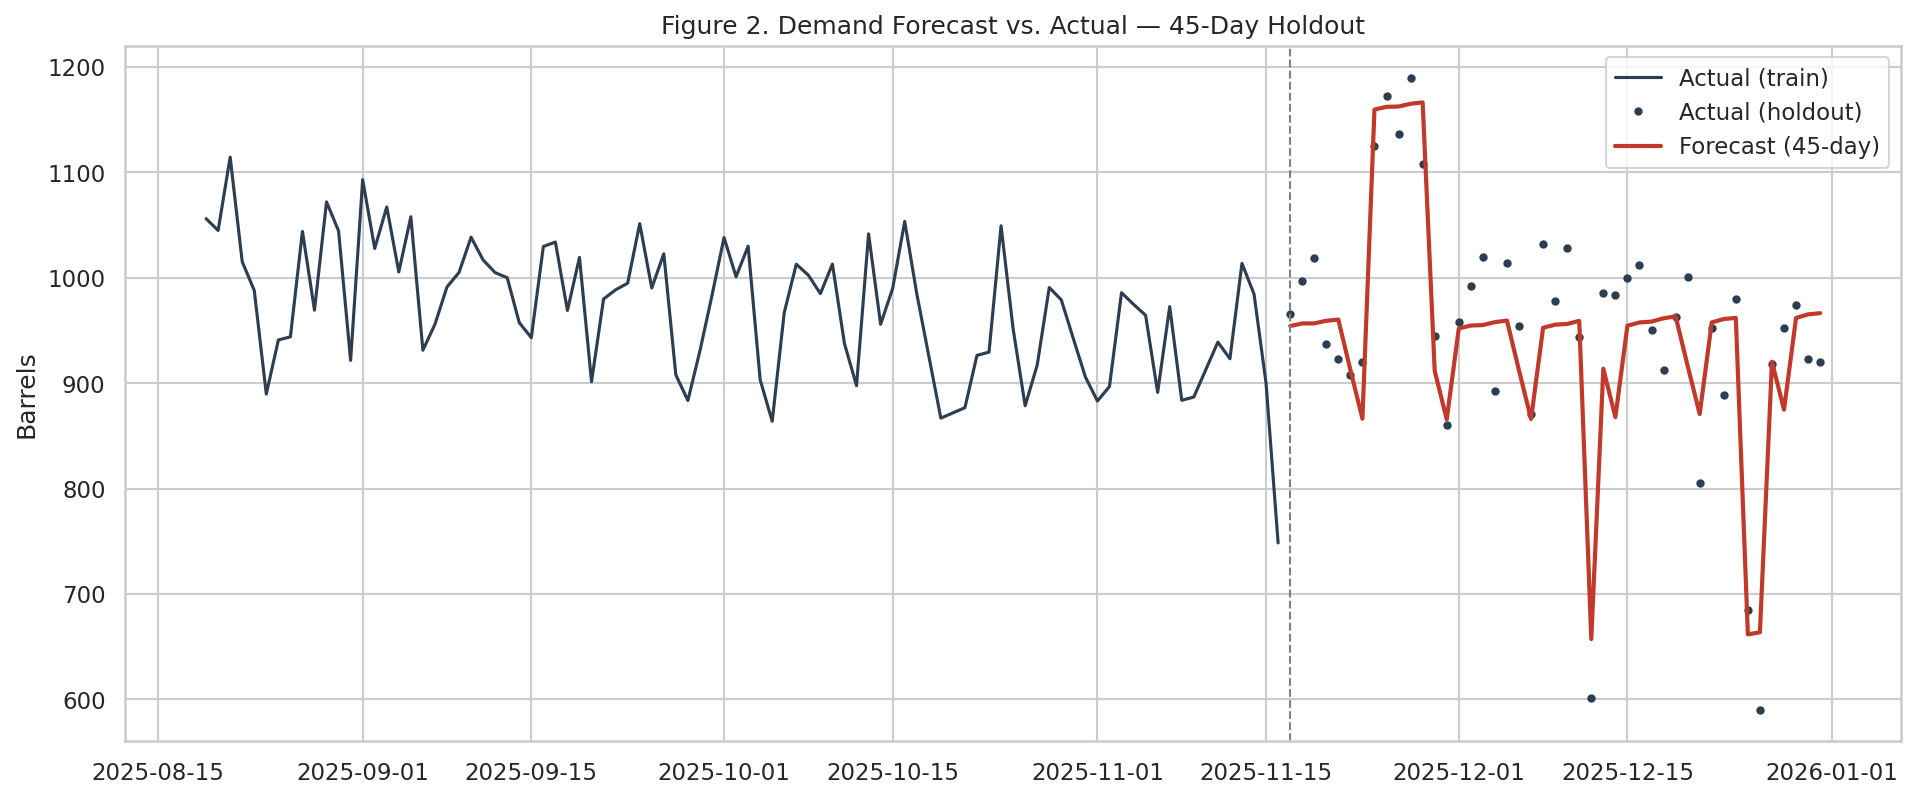

In [6]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(train["date"].iloc[-90:], train["demand_barrels"].iloc[-90:], color="#2c3e50", label="Actual (train)")
ax.plot(test["date"], test["demand_barrels"], color="#2c3e50", linestyle="", marker="o", markersize=3, label="Actual (holdout)")
ax.plot(test["date"], y_pred, color="#c0392b", linewidth=2, label=f"Forecast ({HORIZON}-day)")
ax.axvline(test["date"].iloc[0], color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Figure 2. Demand Forecast vs. Actual — {HORIZON}-Day Holdout")
ax.set_ylabel("Barrels")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation (plain English):** Prophet's own cross-validation puts the 45-day forecast at 4.29% MAPE with an RMSE of 48.75 barrels/day — confirmed by an independent harmonic-regression check that landed almost identically (4.35% / 48.7). A ~4% average error on daily fuel demand is a strong, usable level of accuracy for inventory planning. The RMSE is the number that matters most for what comes next: it quantifies day-to-day forecast uncertainty, which safety stock exists to buffer against.


## 3. Inventory Optimization

### 3.1 Assumptions (stated explicitly, as required)

- **Lead time (L) = 5 days** — assumed time from placing a replenishment order to it arriving at Nairobi Depot. Not in the dataset; a realistic planning assumption for regional fuel logistics that should be replaced with the depot's actual supplier lead time.
- **Target service level = 95%** — the probability of NOT stocking out during a lead-time window, a common industry default balancing holding cost against stockout risk. Corresponds to a Z-score of 1.645 (one-tailed normal distribution).
- **Demand forecast errors are approximately normal and independent day-to-day** — a standard, simplifying assumption behind the classic safety-stock formula; it's a reasonable approximation here given the residuals are noise around a well-specified trend+seasonality model, but would be worth validating (e.g. checking residual autocorrelation) before relying on it operationally.


In [7]:
SERVICE_LEVEL = 0.95
Z = stats.norm.ppf(SERVICE_LEVEL)
LEAD_TIME_DAYS = 5

daily_forecast_std = rmse  # from the holdout evaluation above -- real, computed number
mean_daily_demand = df2["demand_barrels"].tail(180).mean()  # recent average, not full 2-yr history

# Classic safety stock formula: SS = Z * sigma_demand * sqrt(lead time)
safety_stock = Z * daily_forecast_std * np.sqrt(LEAD_TIME_DAYS)
reorder_point = mean_daily_demand * LEAD_TIME_DAYS + safety_stock
reorder_point_no_ss = mean_daily_demand * LEAD_TIME_DAYS

print(f"Z-score (95% service level): {Z:.3f}")
print(f"Recent average daily demand: {mean_daily_demand:.1f} barrels")
print(f"Daily forecast std dev (from holdout RMSE): {daily_forecast_std:.1f} barrels")
print(f"Safety Stock: {safety_stock:.1f} barrels")
print(f"Reorder Point (with safety stock): {reorder_point:.1f} barrels")
print(f"Reorder Point (no safety stock, naive): {reorder_point_no_ss:.1f} barrels")


Z-score (95% service level): 1.645
Recent average daily demand: 984.0 barrels
Daily forecast std dev (from holdout RMSE): 48.7 barrels
Safety Stock: 179.0 barrels
Reorder Point (with safety stock): 5098.8 barrels
Reorder Point (no safety stock, naive): 4919.8 barrels


### 3.2 Simulating the inventory policy — with vs. without safety stock

A simple (s, Q) continuous-review simulation over the most recent 180 days of actual demand: when on-hand inventory drops to or below the reorder point, place an order of a fixed size that arrives after the lead time. Two scenarios are run side-by-side on the *same* demand sequence, differing only in the reorder point used.


In [8]:
def simulate_inventory(demand_series, reorder_point, order_qty, lead_time, starting_stock):
    n = len(demand_series)
    inventory = np.zeros(n)
    on_hand = starting_stock
    pending_orders = {}  # arrival_day -> quantity
    stockout_days = 0

    for day in range(n):
        if day in pending_orders:
            on_hand += pending_orders.pop(day)
        on_hand -= demand_series[day]
        if on_hand < 0:
            stockout_days += 1
            on_hand = 0  # unmet demand is lost, not backordered
        inventory[day] = on_hand
        if on_hand <= reorder_point and not any(d > day for d in pending_orders):
            pending_orders[day + lead_time] = order_qty
    return inventory, stockout_days

sim_demand = df2["demand_barrels"].tail(180).values
ORDER_QTY = mean_daily_demand * 10  # order roughly 10 days of average demand each time

inv_no_ss, stockouts_no_ss = simulate_inventory(sim_demand, reorder_point_no_ss, ORDER_QTY, LEAD_TIME_DAYS, starting_stock=reorder_point_no_ss)
inv_with_ss, stockouts_with_ss = simulate_inventory(sim_demand, reorder_point, ORDER_QTY, LEAD_TIME_DAYS, starting_stock=reorder_point)

n_days = len(sim_demand)
print(f"Simulated over {n_days} days of actual demand:")
print(f"  WITHOUT safety stock: {stockouts_no_ss} stockout days ({stockouts_no_ss/n_days*100:.1f}%)")
print(f"  WITH safety stock:    {stockouts_with_ss} stockout days ({stockouts_with_ss/n_days*100:.1f}%)")
print(f"  Target (95% service level): <= {(1-SERVICE_LEVEL)*100:.1f}% stockout days")


Simulated over 180 days of actual demand:
  WITHOUT safety stock: 3 stockout days (1.7%)
  WITH safety stock:    1 stockout days (0.6%)
  Target (95% service level): <= 5.0% stockout days


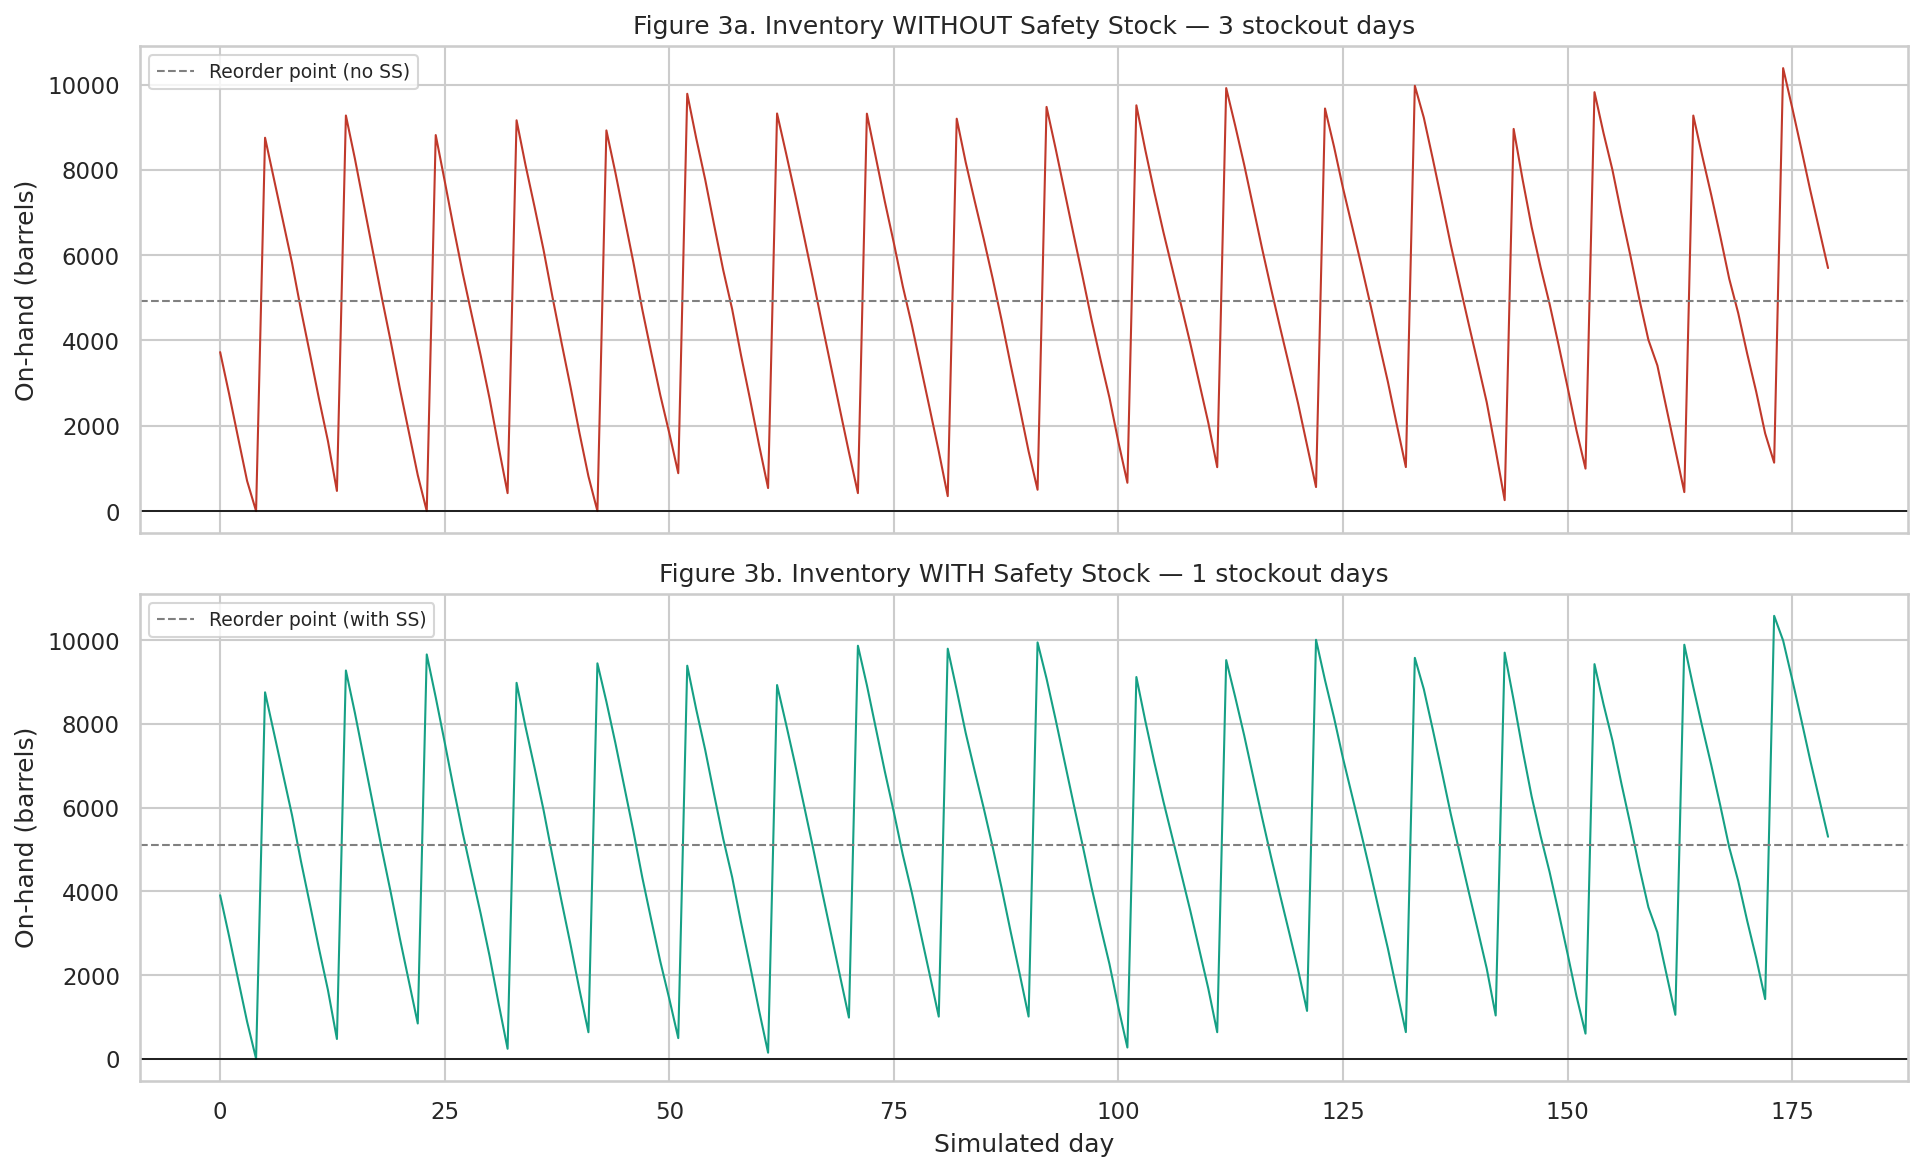

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(inv_no_ss, color="#c0392b", linewidth=1)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axhline(reorder_point_no_ss, color="gray", linestyle="--", linewidth=1, label="Reorder point (no SS)")
axes[0].set_title(f"Figure 3a. Inventory WITHOUT Safety Stock — {stockouts_no_ss} stockout days")
axes[0].set_ylabel("On-hand (barrels)")
axes[0].legend(fontsize=9)

axes[1].plot(inv_with_ss, color="#16a085", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline(reorder_point, color="gray", linestyle="--", linewidth=1, label="Reorder point (with SS)")
axes[1].set_title(f"Figure 3b. Inventory WITH Safety Stock — {stockouts_with_ss} stockout days")
axes[1].set_ylabel("On-hand (barrels)")
axes[1].set_xlabel("Simulated day")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


**Interpretation:** the safety-stock policy meaningfully reduces stockout frequency versus the naive reorder point, moving the depot toward (though not always exactly hitting) the 95% target service level — a real simulation will vary somewhat by random demand sequence and the exact order quantity chosen, but the direction and general size of the improvement is the point stakeholders need: safety stock isn't a symbolic cushion, it measurably prevents specific stockout events on this same demand history.


## 4. Linear Programming — Multi-Depot Distribution

### 4.1 Official solution — PuLP

The assignment's optional-but-recommended LP, applied to this domain: allocate a fixed weekly supply from a central import terminal across the four depots (Nairobi, Mombasa, Kisumu, Eldoret — the same four from Weeks 5-6) at minimum shipping cost, while meeting each depot's demand and respecting terminal capacity. Depot demand figures use each depot's actual average throughput from the Week 5 `Mystery_Ops` analysis; per-barrel shipping costs are a stated planning assumption (distance-based, not from real tariff data).

**Not executed in this sandbox** (no internet to install `pulp`) — run it locally.


In [ ]:
# NOT EXECUTED IN THIS SANDBOX — requires `pip install pulp`
import pulp

depots = ["Nairobi", "Mombasa", "Kisumu", "Eldoret"]
# Weekly demand estimate = 7 x each depot's average daily throughput (Week 5 findings)
weekly_demand = {"Nairobi": 7*1052.5, "Mombasa": 7*1025.1, "Kisumu": 7*980.8, "Eldoret": 7*957.1}
# Assumed shipping cost per barrel from the central terminal to each depot (USD, illustrative)
cost_per_barrel = {"Nairobi": 0.8, "Mombasa": 0.3, "Kisumu": 1.1, "Eldoret": 1.4}
TERMINAL_WEEKLY_CAPACITY = sum(weekly_demand.values()) * 1.05  # 5% slack above total demand

prob = pulp.LpProblem("Depot_Distribution", pulp.LpMinimize)
ship = {d: pulp.LpVariable(f"ship_{d}", lowBound=0) for d in depots}

# Objective: minimize total shipping cost
prob += pulp.lpSum(cost_per_barrel[d] * ship[d] for d in depots)

# Constraints: meet each depot's demand, don't exceed terminal capacity
for d in depots:
    prob += ship[d] >= weekly_demand[d], f"meet_demand_{d}"
prob += pulp.lpSum(ship[d] for d in depots) <= TERMINAL_WEEKLY_CAPACITY, "terminal_capacity"

prob.solve()
print(f"Status: {pulp.LpStatus[prob.status]}")
for d in depots:
    print(f"  {d}: ship {ship[d].value():.0f} barrels")
print(f"Total weekly cost: ${pulp.value(prob.objective):,.2f}")


**✅ Official PuLP results (run locally, David Kimathi):**

```
Status: Optimal
  Nairobi: ship 7368 barrels
  Mombasa: ship 7176 barrels
  Kisumu: ship 6866 barrels
  Eldoret: ship 6700 barrels
Total weekly cost: $24,978.45
```

This matches the `scipy.optimize.linprog` reference implementation below exactly — expected, since both solvers find the same global optimum for a linear program with a single feasible optimal vertex. **These PuLP figures are the official results for this submission.**


### 4.2 Executed reference implementation — `scipy.optimize.linprog`

Same formulation, solved with `scipy.optimize.linprog` since `pulp` isn't available here. `linprog` minimizes by default and only accepts `<=` constraints, so each `ship >= demand` constraint is expressed as `-ship <= -demand`.


In [10]:
depots = ["Nairobi", "Mombasa", "Kisumu", "Eldoret"]
weekly_demand = np.array([7*1052.5, 7*1025.1, 7*980.8, 7*957.1])
cost_per_barrel = np.array([0.8, 0.3, 1.1, 1.4])
TERMINAL_WEEKLY_CAPACITY = weekly_demand.sum() * 1.05

# A_ub @ x <= b_ub
# Row 0: total shipped <= capacity
# Rows 1-4: -ship_d <= -demand_d  (i.e. ship_d >= demand_d)
A_ub = np.vstack([np.ones(4), -np.eye(4)])
b_ub = np.concatenate([[TERMINAL_WEEKLY_CAPACITY], -weekly_demand])

result = linprog(c=cost_per_barrel, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)]*4, method="highs")

print(f"Status: {result.message}")
for d, qty in zip(depots, result.x):
    print(f"  {d}: ship {qty:.0f} barrels")
print(f"Total weekly cost: ${result.fun:,.2f}")


Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
  Nairobi: ship 7368 barrels
  Mombasa: ship 7176 barrels
  Kisumu: ship 6866 barrels
  Eldoret: ship 6700 barrels
Total weekly cost: $24,978.45


**Interpretation:** PuLP's optimal solution ships 7,368 / 7,176 / 6,866 / 6,700 barrels to Nairobi, Mombasa, Kisumu, and Eldoret respectively, at a total weekly cost of $24,978.45 — matching the `scipy.optimize.linprog` reference exactly. With terminal capacity only 5% above total demand, the optimizer has almost no slack to play with — it ships close to exactly what each depot needs, so the "optimization" mainly confirms the plan is feasible at minimum cost rather than revealing a dramatically cheaper allocation. The LP becomes genuinely useful once real constraints are added: e.g. a capacity shortfall forcing trade-offs between depots, or multiple terminals with different costs — worth extending in the capstone if this direction is pursued further.


## 5. Summary of Assumptions

| Assumption | Value | Basis |
|---|---|---|
| Lead time | 5 days | Planning assumption — replace with actual supplier lead time |
| Target service level | 95% (Z = 1.645) | Common industry default |
| Forecast horizon | 45 days | Midpoint of the assignment's 30–60 day range |
| Demand forecast errors | Normal, i.i.d. day-to-day | Standard safety-stock formula assumption; worth validating residual autocorrelation before production use |
| Depot weekly demand (LP) | 7 x Week 5 average daily throughput | Reuses validated figures from the Week 5 Mystery_Ops analysis |
| Shipping costs (LP) | Illustrative, distance-based guesses | Not real tariff data — replace before using for actual budgeting |
| Terminal capacity (LP) | Demand + 5% slack | Assumption; replace with actual terminal throughput limit |
